# Employee Attrition Modelling Pipeline

This notebook builds a leakage-safe modelling pipeline for the employee attrition classification task using the reduced-column dataset logic from `EDA_rm_col.ipynb`.

## Scope
- Use the no-PCA path
- Compare several classifiers, including blackbox models
- Validate with stratified cross-validation
- Tune the strongest finalists
- Evaluate on a held-out test set
- End with a recommendation for both the strongest overall benchmark and the strongest blackbox candidate

## Why this notebook differs from the EDA notebook
- Preprocessing is wrapped inside sklearn pipelines so train/test leakage is avoided
- Class imbalance is handled with imbalance-aware metrics and class weights
- Model selection is based primarily on PR-AUC because attrition is the minority class


In [21]:
%pip install Jinja2 scikit-learn pandas numpy seaborn matplotlib -q


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [22]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import (
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)

RANDOM_STATE = 42

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13


## 1. Load The Reduced-Column Dataset

The reduced version follows the feature removal choices already documented in `EDA_rm_col.ipynb`:

- Remove constant columns
- Remove identifier / non-informative columns
- Remove high-VIF or overlapping-meaning columns:
  `JobLevel`, `YearsAtCompany`, `WorkLifeBalance`, `MonthlyIncome`,
  `PerformanceRating`, `JobInvolvement`, `HourlyRate`, `DailyRate`


In [23]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

original_shape = df.shape


print(f"Original shape: {original_shape}")
print(f"Shape after reductions: {df.shape}")
print()
print("Target distribution:")
print(df["Attrition"].value_counts())

df.head()


Original shape: (1470, 35)
Shape after reductions: (1470, 35)

Target distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2



```
Original Data (1,470 samples)
│
├─ Training: 60% (882 samples) → Model training via 5-fold CV
├─ Validation: 20% (294 samples) → Threshold tuning (F2 optimization)
└─ Test: 20% (294 samples) → Final evaluation (truly held-out)
```

In [24]:
X = df.drop(columns=["Attrition"]).copy()
y = df["Attrition"].map({"Yes": 1, "No": 0})

# First split: 80% train+val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

# Second split: split the 80% into 75% model training, 25% validation
# This gives us: 60% model training, 20% validation, 20% test
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    stratify=y_temp,
    random_state=RANDOM_STATE,
)

numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()

categorical_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print()
print("Data Split Summary (Train/Validation/Test):")
print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print("="*50)
print()
print(f"Model training shape: {X_train.shape}")
print(f"Full data positive rate: {round(y.mean(), 4)} (Attrition%)")
print()
print(f"Validation shape: {X_val.shape}")
print(f"Validation positive rate: {round(y_val.mean(), 4)} (Attrition%)")
print()
print(f"Test shape: {X_test.shape}")
print(f"Test positive rate: {round(y_test.mean(), 4)} (Attrition%)")
print()
print(f"Train positive rate: {round(y_train.mean(), 4)} (Attrition%)")
print("Class Distribution by Set:")

Categorical features (8): ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']

Data Split Summary (Train/Validation/Test):
Numeric features (26): ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Model training shape: (882, 34)
Full data positive rate: 0.1612 (Attrition%)

Validation shape: (294, 34)
Validation positive rate: 0.1599 (Attrition%)

Test shape: (294, 34)
Test positive rate: 0.1599 (Attrition%)

Train positive rate: 0.1621 (Attrition%)
Class Distribution by Set:


## 2. Modelling Strategy

A few choices here are intentional:

- `PR-AUC` is the main selection metric because attrition is the minority class.
- `ROC-AUC`, `F1`, `Recall`, `Precision`, and `Balanced Accuracy` are tracked as supporting metrics.
- Preprocessing is done inside each pipeline so cross-validation stays leakage-safe.
- For imbalance handling, the notebook leans on class weights rather than applying SMOTE outside CV.


In [25]:
preprocessor_scaled = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "onehot",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            sparse_output=False,
                        ),
                    ),
                ]
            ),
            categorical_features,
        ),
    ]
)

preprocessor_unscaled = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                ]
            ),
            numeric_features,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "onehot",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            sparse_output=False,
                        ),
                    ),
                ]
            ),
            categorical_features,
        ),
    ]
)

candidate_models = {
    "Logistic Regression": {
        "pipeline": Pipeline(
            steps=[
                ("prep", preprocessor_scaled),
                (
                    "model",
                    LogisticRegression(
                        max_iter=2000,
                        class_weight="balanced",
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
        "is_blackbox": False,
    },
    "KNN": {
        "pipeline": Pipeline(
            steps=[
                ("prep", preprocessor_scaled),
                ("model", KNeighborsClassifier(n_neighbors=11)),
            ]
        ),
        "is_blackbox": True,
    },
    "SVM (RBF)": {
        "pipeline": Pipeline(
            steps=[
                ("prep", preprocessor_scaled),
                (
                    "model",
                    SVC(
                        kernel="rbf",
                        C=1.0,
                        gamma="scale",
                        class_weight="balanced",
                        probability=True,
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
        "is_blackbox": True,
    },
    "Random Forest": {
        "pipeline": Pipeline(
            steps=[
                ("prep", preprocessor_unscaled),
                (
                    "model",
                    RandomForestClassifier(
                        n_estimators=400,
                        min_samples_leaf=2,
                        class_weight="balanced_subsample",
                        random_state=RANDOM_STATE,
                        n_jobs=-1,
                    ),
                ),
            ]
        ),
        "is_blackbox": True,
    },
    "Extra Trees": {
        "pipeline": Pipeline(
            steps=[
                ("prep", preprocessor_unscaled),
                (
                    "model",
                    ExtraTreesClassifier(
                        n_estimators=500,
                        min_samples_leaf=2,
                        class_weight="balanced",
                        random_state=RANDOM_STATE,
                        n_jobs=-1,
                    ),
                ),
            ]
        ),
        "is_blackbox": True,
    },
    "HistGradientBoosting": {
        "pipeline": Pipeline(
            steps=[
                ("prep", preprocessor_unscaled),
                (
                    "model",
                    HistGradientBoostingClassifier(
                        learning_rate=0.05,
                        max_depth=6,
                        max_iter=300,
                        min_samples_leaf=20,
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
        "is_blackbox": True,
    },
}

scoring = {
    "pr_auc": "average_precision",
    "roc_auc": "roc_auc",
    "f1": "f1",
    "recall": "recall",
    "precision": "precision",
    "balanced_accuracy": "balanced_accuracy",
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


In [26]:
cv_rows = []

for name, meta in candidate_models.items():
    scores = cross_validate(
        meta["pipeline"],
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
    )

    row = {
        "model": name,
        "is_blackbox": meta["is_blackbox"],
    }
    for metric in scoring:
        row[f"cv_mean_{metric}"] = scores[f"test_{metric}"].mean()
        row[f"cv_std_{metric}"] = scores[f"test_{metric}"].std()
    cv_rows.append(row)

cv_results = (
    pd.DataFrame(cv_rows)
    .sort_values(
        ["cv_mean_pr_auc", "cv_mean_recall", "cv_mean_roc_auc"],
        ascending=False,
    )
    .reset_index(drop=True)
)

cv_results.style.format(
    {
        col: "{:.3f}"
        for col in cv_results.columns
        if col.startswith("cv_mean_") or col.startswith("cv_std_")
    }
)


,model,is_blackbox,cv_mean_pr_auc,cv_std_pr_auc,cv_mean_roc_auc,cv_std_roc_auc,cv_mean_f1,cv_std_f1,cv_mean_recall,cv_std_recall,cv_mean_precision,cv_std_precision,cv_mean_balanced_accuracy,cv_std_balanced_accuracy
0,Logistic Regression,False,0.582,0.037,0.825,0.007,0.495,0.044,0.727,0.040,0.377,0.048,0.745,0.028
1,SVM (RBF),True,0.555,0.056,0.812,0.013,0.507,0.049,0.559,0.032,0.465,0.063,0.716,0.027
2,Random Forest,True,0.549,0.076,0.795,0.018,0.285,0.073,0.175,0.046,0.767,0.200,0.582,0.027
3,Extra Trees,True,0.521,0.064,0.782,0.023,0.391,0.056,0.280,0.040,0.655,0.119,0.625,0.024
4,HistGradientBoosting,True,0.500,0.045,0.781,0.030,0.361,0.099,0.258,0.088,0.633,0.090,0.615,0.044
5,KNN,True,0.325,0.047,0.690,0.026,0.053,0.049,0.028,0.026,0.600,0.490,0.513,0.014


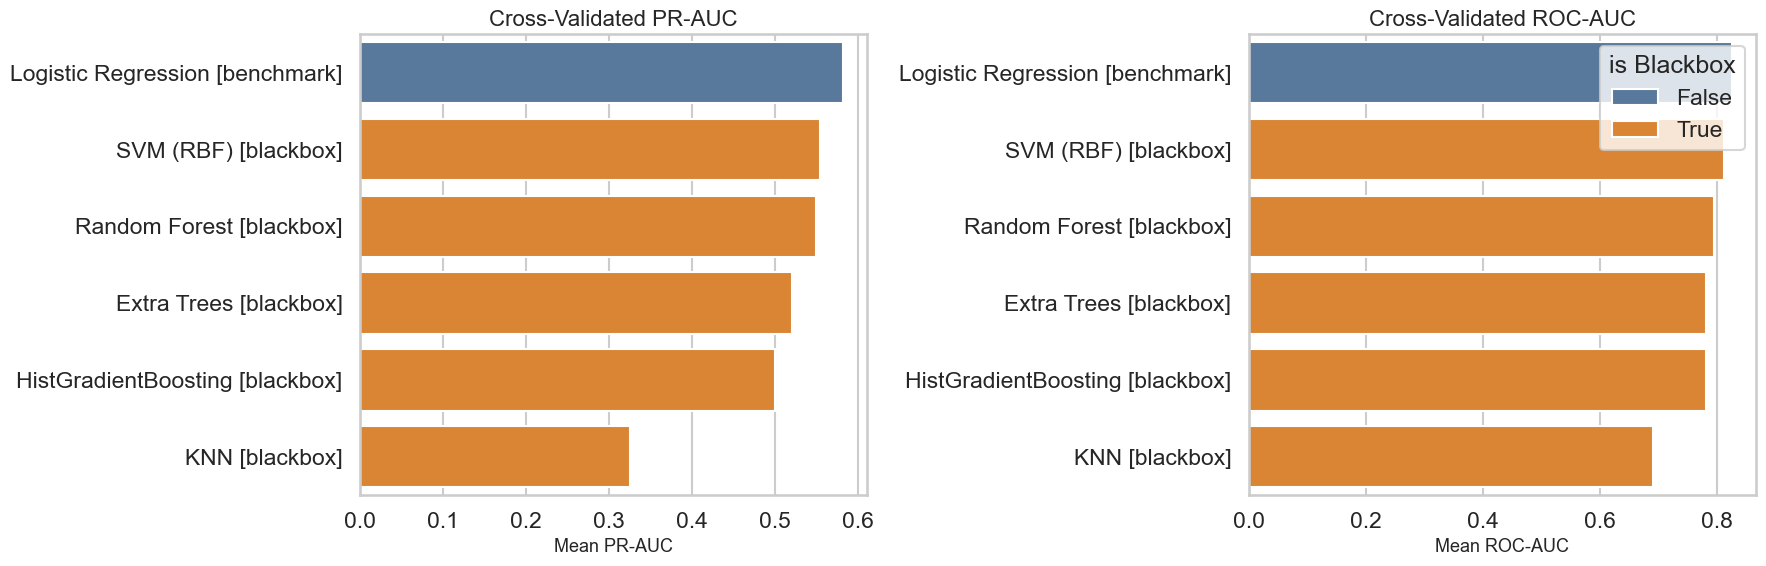

In [27]:
plot_df = cv_results.copy()
plot_df["model_label"] = np.where(
    plot_df["is_blackbox"],
    plot_df["model"] + " [blackbox]",
    plot_df["model"] + " [benchmark]",
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(
    data=plot_df,
    y="model_label",
    x="cv_mean_pr_auc",
    hue="is_blackbox",
    dodge=False,
    palette=["#4C78A8", "#F58518"],
    ax=axes[0],
)
axes[0].set_title("Cross-Validated PR-AUC")
axes[0].set_xlabel("Mean PR-AUC")
axes[0].set_ylabel("")
axes[0].legend_.remove()

sns.barplot(
    data=plot_df,
    y="model_label",
    x="cv_mean_roc_auc",
    hue="is_blackbox",
    dodge=False,
    palette=["#4C78A8", "#F58518"],
    ax=axes[1],
)
axes[1].set_title("Cross-Validated ROC-AUC")
axes[1].set_xlabel("Mean ROC-AUC")
axes[1].set_ylabel("")
axes[1].legend(title="is Blackbox")

plt.tight_layout()
plt.show()


In [28]:
best_cv_overall = cv_results.iloc[0]
best_cv_blackbox = (
    cv_results[cv_results["is_blackbox"]]
    .sort_values(["cv_mean_pr_auc", "cv_mean_recall", "cv_mean_roc_auc"], ascending=False)
    .iloc[0]
)

print("Best overall CV model:")
print(best_cv_overall[["model", "cv_mean_pr_auc", "cv_mean_roc_auc", "cv_mean_recall"]])
print()
print("Best blackbox CV model:")
print(best_cv_blackbox[["model", "cv_mean_pr_auc", "cv_mean_roc_auc", "cv_mean_recall"]])


Best overall CV model:
model              Logistic Regression
cv_mean_pr_auc                0.581688
cv_mean_roc_auc               0.825213
cv_mean_recall                 0.72734
Name: 0, dtype: object

Best blackbox CV model:
model              SVM (RBF)
cv_mean_pr_auc      0.554544
cv_mean_roc_auc     0.811698
cv_mean_recall      0.559113
Name: 1, dtype: object


## 3. Hyperparameter Tuning via Cross-Validation

To keep the notebook efficient but still iterative, I tune:

- the top 2 models overall by cross-validated PR-AUC
- plus the top blackbox model if it is not already in that top 2


In [29]:
finalists = cv_results["model"].head(2).tolist()
best_blackbox_name = best_cv_blackbox["model"]
if best_blackbox_name not in finalists:
    finalists.append(best_blackbox_name)

finalists


['Logistic Regression', 'SVM (RBF)']

In [30]:
search_spaces = {
    "Logistic Regression": {
        "model__C": np.logspace(-2, 2, 10),
        "model__solver": ["lbfgs"],
        "model__class_weight": ["balanced"],
    },
    "KNN": {
        "model__n_neighbors": [5, 7, 9, 11, 15, 21],
        "model__weights": ["uniform", "distance"],
        "model__p": [1, 2],
    },
    "SVM (RBF)": {
        "model__C": [0.5, 1, 2, 5, 10],
        "model__gamma": ["scale", 0.01, 0.03, 0.05, 0.1],
    },
    "Random Forest": {
        "model__n_estimators": [300, 500, 700],
        "model__max_depth": [None, 8, 12, 16],
        "model__min_samples_leaf": [1, 2, 4, 6],
        "model__min_samples_split": [2, 5, 10],
        "model__max_features": ["sqrt", "log2", None],
        "model__class_weight": ["balanced", "balanced_subsample"],
    },
    "Extra Trees": {
        "model__n_estimators": [300, 500, 700],
        "model__max_depth": [None, 8, 12, 16],
        "model__min_samples_leaf": [1, 2, 4, 6],
        "model__min_samples_split": [2, 5, 10],
        "model__max_features": ["sqrt", "log2", None],
        "model__class_weight": ["balanced", "balanced_subsample"],
    },
    "HistGradientBoosting": {
        "model__learning_rate": [0.03, 0.05, 0.08, 0.1],
        "model__max_depth": [None, 4, 6, 8],
        "model__max_leaf_nodes": [15, 31, 63],
        "model__min_samples_leaf": [10, 20, 30],
        "model__l2_regularization": [0.0, 0.1, 0.5, 1.0],
        "model__max_iter": [200, 300, 400],
    },
}

n_iter_lookup = {
    "Logistic Regression": 10,
    "KNN": 10,
    "SVM (RBF)": 10,
    "Random Forest": 12,
    "Extra Trees": 12,
    "HistGradientBoosting": 12,
}

tuned_searches = {}
tuned_rows = []

for name in finalists:
    search = RandomizedSearchCV(
        estimator=candidate_models[name]["pipeline"],
        param_distributions=search_spaces[name],
        n_iter=n_iter_lookup[name],
        scoring="average_precision",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=1,
        refit=True,
    )
    # Step 1: Hyperparameter tuning via cross-validation on TRAINING set
    search.fit(X_train, y_train)
    tuned_searches[name] = search

    # Step 2: Evaluate on VALIDATION set to select best model
    val_proba = search.best_estimator_.predict_proba(X_val)[:, 1]
    val_pred = (val_proba >= 0.5).astype(int)

    tuned_rows.append(
        {
            "model": name,
            "is_blackbox": candidate_models[name]["is_blackbox"],
            "best_params": search.best_params_,
            "cv_best_pr_auc": search.best_score_,
            # Validation metrics only (for model selection)
            "val_pr_auc": average_precision_score(y_val, val_proba),
            "val_roc_auc": roc_auc_score(y_val, val_proba),
            "val_f1": f1_score(y_val, val_pred),
            "val_recall": recall_score(y_val, val_pred),
            "val_precision": precision_score(y_val, val_pred, zero_division=0),
            "val_balanced_accuracy": balanced_accuracy_score(y_val, val_pred),
        }
    )

tuned_results = (
    pd.DataFrame(tuned_rows)
    .sort_values(["val_pr_auc", "val_recall"], ascending=False)
    .reset_index(drop=True)
)

tuned_results


,model,is_blackbox,best_params,cv_best_pr_auc,val_pr_auc,val_roc_auc,val_f1,val_recall,val_precision,val_balanced_accuracy
0,SVM (RBF),True,"{'model__gamma': 0.01, 'model__C': 0.5}",0.601993,0.584116,0.802222,0.540541,0.425532,0.740741,0.698596
1,Logistic Regression,False,"{'model__solver': 'lbfgs', 'model__class_weigh...",0.606686,0.582321,0.803859,0.496241,0.702128,0.383721,0.743776


In [31]:
# Step 3: Final test evaluation (truly held-out)
best_overall_final = tuned_results.iloc[0]
best_overall_name = best_overall_final["model"]
best_overall_estimator = tuned_searches[best_overall_name].best_estimator_

best_blackbox_final = (
    tuned_results[tuned_results["is_blackbox"]]
    .sort_values(["val_pr_auc", "val_recall"], ascending=False)
    .iloc[0]
)
best_blackbox_name = best_blackbox_final["model"]
best_blackbox_estimator = tuned_searches[best_blackbox_name].best_estimator_

# NOW evaluate on test set (once, for final report)
overall_test_proba = best_overall_estimator.predict_proba(X_test)[:, 1]
overall_test_pred = (overall_test_proba >= 0.5).astype(int)

blackbox_test_proba = best_blackbox_estimator.predict_proba(X_test)[:, 1]
blackbox_test_pred = (blackbox_test_proba >= 0.5).astype(int)

print("="*70)
print("FINAL TEST SET EVALUATION (Threshold = 0.50)")
print("="*70)
print()
print(f"Best Overall Model: {best_overall_name}")
print(f"  PR-AUC:            {average_precision_score(y_test, overall_test_proba):.3f}")
print(f"  ROC-AUC:           {roc_auc_score(y_test, overall_test_proba):.3f}")
print(f"  Recall:            {recall_score(y_test, overall_test_pred):.3f}")
print(f"  Precision:         {precision_score(y_test, overall_test_pred, zero_division=0):.3f}")
print(f"  F1:                {f1_score(y_test, overall_test_pred):.3f}")
print(f"  Balanced Accuracy: {balanced_accuracy_score(y_test, overall_test_pred):.3f}")
print()
print(f"Best Blackbox Model: {best_blackbox_name}")
print(f"  PR-AUC:            {average_precision_score(y_test, blackbox_test_proba):.3f}")
print(f"  ROC-AUC:           {roc_auc_score(y_test, blackbox_test_proba):.3f}")
print(f"  Recall:            {recall_score(y_test, blackbox_test_pred):.3f}")
print(f"  Precision:         {precision_score(y_test, blackbox_test_pred, zero_division=0):.3f}")
print(f"  F1:                {f1_score(y_test, blackbox_test_pred):.3f}")
print(f"  Balanced Accuracy: {balanced_accuracy_score(y_test, blackbox_test_pred):.3f}")
print()
print(f"Chosen Hyperparameters for {best_blackbox_name}:")
print(best_blackbox_final["best_params"])

FINAL TEST SET EVALUATION (Threshold = 0.50)

Best Overall Model: SVM (RBF)
  PR-AUC:            0.547
  ROC-AUC:           0.786
  Recall:            0.319
  Precision:         0.652
  F1:                0.429
  Balanced Accuracy: 0.643

Best Blackbox Model: SVM (RBF)
  PR-AUC:            0.547
  ROC-AUC:           0.786
  Recall:            0.319
  Precision:         0.652
  F1:                0.429
  Balanced Accuracy: 0.643

Chosen Hyperparameters for SVM (RBF):
{'model__gamma': 0.01, 'model__C': 0.5}


## 4. Threshold Tuning For The Recommended Blackbox Model

The default `0.50` threshold is often not ideal for imbalanced classification.
Here I tune the threshold on the **validation set** for the chosen blackbox finalist using the `F2` score, which places more emphasis on recall.


**Note on preventing leakage:** The threshold is tuned on a held-out validation set (20% of original data) that was never used during model training (60% of original data). This prevents overfitting the threshold to training data characteristics. Final evaluation uses an independent test set (20% of original data).

In [32]:
recommended_blackbox_name = best_blackbox_final["model"]  #"SVM (RBF)"
recommended_blackbox_estimator = tuned_searches[recommended_blackbox_name].best_estimator_

# Step 2: Tune threshold on validation set
val_proba_blackbox = recommended_blackbox_estimator.predict_proba(X_val)[:, 1]
threshold_grid = np.linspace(0.20, 0.80, 61)

threshold_rows = []
for threshold in threshold_grid:
    preds = (val_proba_blackbox >= threshold).astype(int)
    precision = precision_score(y_val, preds, zero_division=0)
    recall = recall_score(y_val, preds)
    f1 = f1_score(y_val, preds)
    f2 = (
        5 * precision * recall / (4 * precision + recall)
        if (4 * precision + recall) > 0
        else 0
    )
    threshold_rows.append(
        {
            "threshold": threshold,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "f2": f2,
            "balanced_accuracy": balanced_accuracy_score(y_val, preds),
        }
    )

threshold_results = pd.DataFrame(threshold_rows).sort_values(
    ["f2", "recall", "balanced_accuracy"],
    ascending=False,
)

threshold_results.head(10)


,threshold,precision,recall,f1,f2,balanced_accuracy
14,0.34,0.588235,0.638298,0.612245,0.627615,0.776639
9,0.29,0.576923,0.638298,0.606061,0.625000,0.774615
10,0.30,0.576923,0.638298,0.606061,0.625000,0.774615
11,0.31,0.576923,0.638298,0.606061,0.625000,0.774615
12,0.32,0.576923,0.638298,0.606061,0.625000,0.774615
13,0.33,0.576923,0.638298,0.606061,0.625000,0.774615
8,0.28,0.545455,0.638298,0.588235,0.617284,0.768542
7,0.27,0.526316,0.638298,0.576923,0.612245,0.764493
15,0.35,0.591837,0.617021,0.604167,0.611814,0.768025
6,0.26,0.517241,0.638298,0.571429,0.609756,0.762469


In [33]:
# Step 3: NOW report on test set with both thresholds

selected_threshold = float(threshold_results.iloc[0]["threshold"])
test_proba_blackbox = recommended_blackbox_estimator.predict_proba(X_test)[:, 1]

print(f"\nThreshold tuned on validation set:")
print(f"Selected threshold: {selected_threshold:.2f}")
print(f"\nEvaluating on TEST set with both default (0.50) and tuned ({selected_threshold:.2f}) thresholds:")
print()

threshold_eval_rows = []
for threshold in [0.50, selected_threshold]:
    preds = (test_proba_blackbox >= threshold).astype(int)
    threshold_eval_rows.append(
        {
            "threshold": threshold,
            "pr_auc": average_precision_score(y_test, test_proba_blackbox),
            "roc_auc": roc_auc_score(y_test, test_proba_blackbox),
            "f1": f1_score(y_test, preds),
            "recall": recall_score(y_test, preds),
            "precision": precision_score(y_test, preds, zero_division=0),
            "balanced_accuracy": balanced_accuracy_score(y_test, preds),
            "positives_predicted": int(preds.sum()),
        }

    )


threshold_test_results = pd.DataFrame(threshold_eval_rows)
threshold_test_results


Threshold tuned on validation set:
Selected threshold: 0.34

Evaluating on TEST set with both default (0.50) and tuned (0.34) thresholds:



,threshold,pr_auc,roc_auc,f1,recall,precision,balanced_accuracy,positives_predicted
0,0.50,0.546967,0.785899,0.428571,0.319149,0.652174,0.643380,23
1,0.34,0.546967,0.785899,0.510204,0.531915,0.490196,0.713326,51


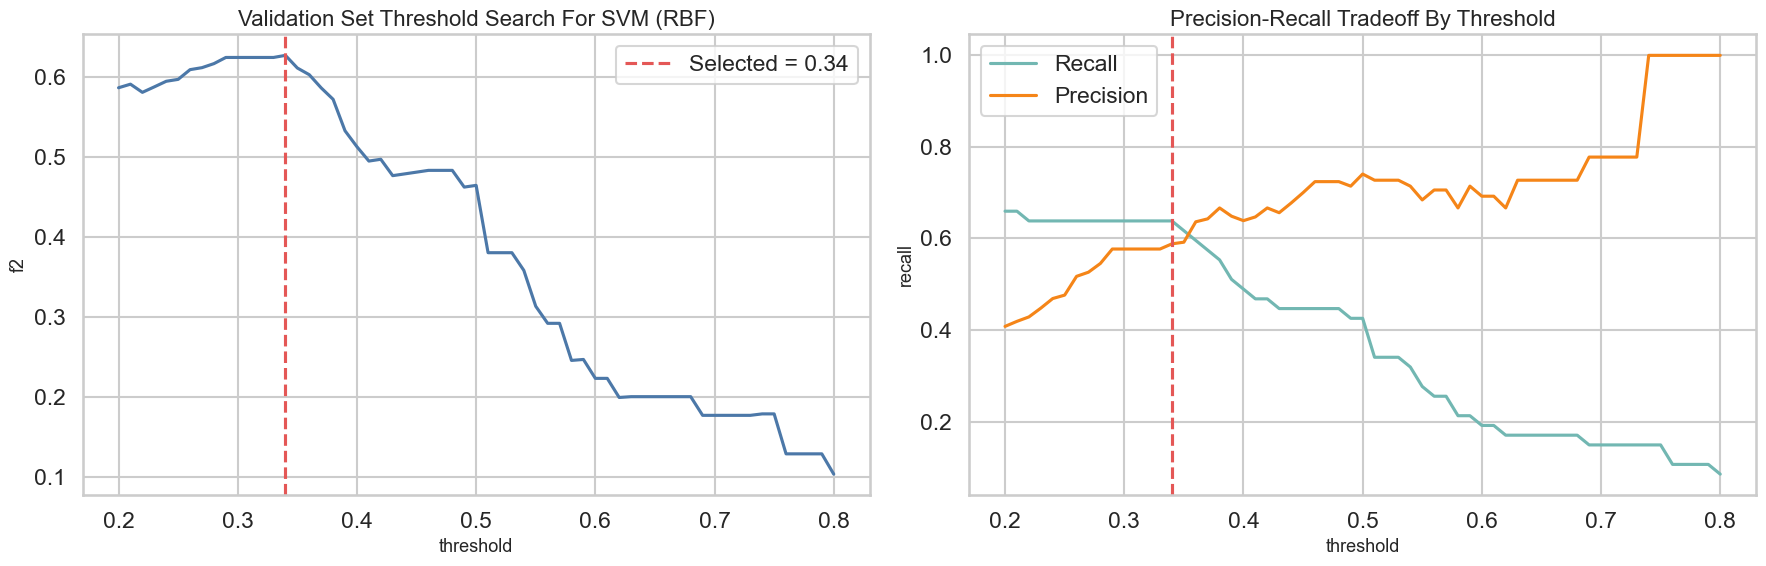

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.lineplot(
    data=threshold_results.sort_values("threshold"),
    x="threshold",
    y="f2",
    ax=axes[0],
    color="#4C78A8",
)
axes[0].axvline(selected_threshold, color="#E45756", linestyle="--", label=f"Selected = {selected_threshold:.2f}")
axes[0].set_title(f"Validation Set Threshold Search For {recommended_blackbox_name}")
axes[0].legend()

sns.lineplot(
    data=threshold_results.sort_values("threshold"),
    x="threshold",
    y="recall",
    ax=axes[1],
    color="#72B7B2",
    label="Recall",
)
sns.lineplot(
    data=threshold_results.sort_values("threshold"),
    x="threshold",
    y="precision",
    ax=axes[1],
    color="#F58518",
    label="Precision",
)
axes[1].axvline(selected_threshold, color="#E45756", linestyle="--")
axes[1].set_title("Precision-Recall Tradeoff By Threshold")

plt.tight_layout()
plt.show()


## 5. Final Evaluation Plots


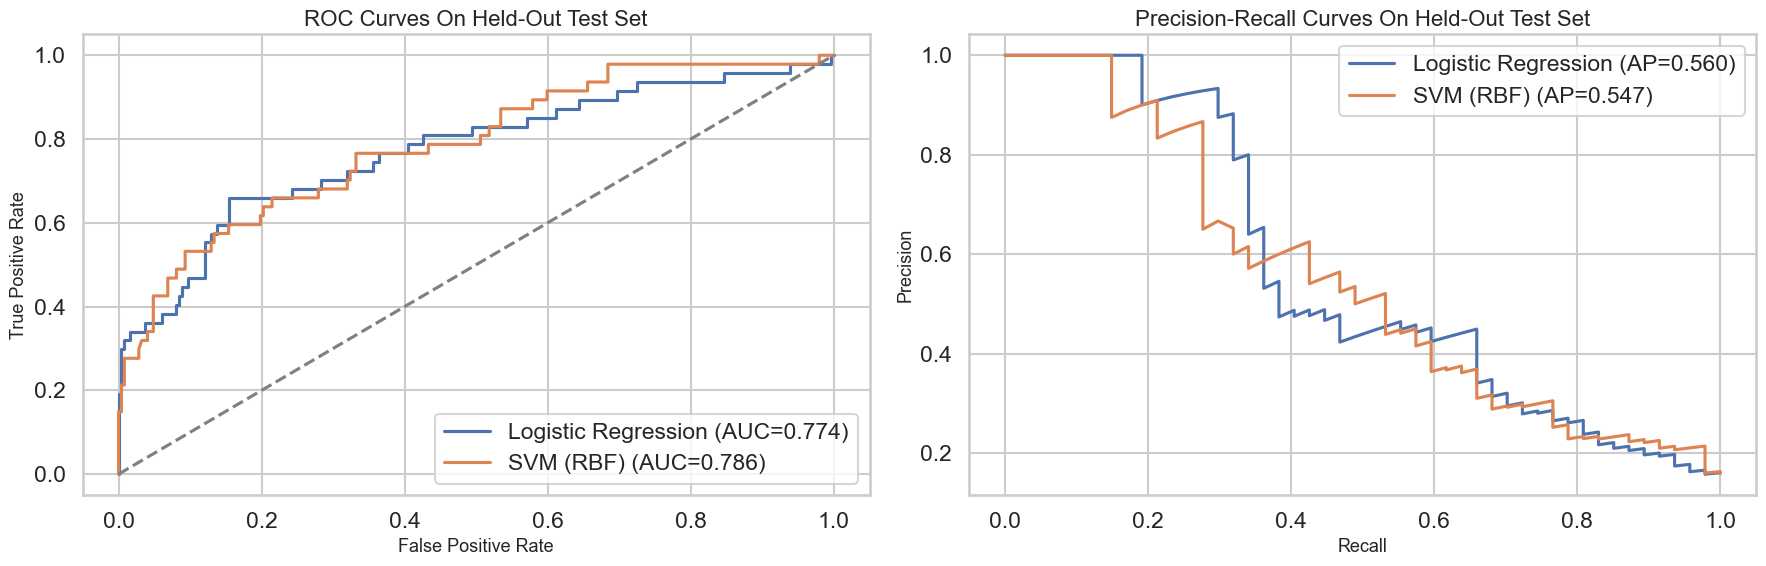

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for name in finalists:
    estimator = tuned_searches[name].best_estimator_
    proba = estimator.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, proba)
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, proba)

    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")
    axes[1].plot(recall_curve, precision_curve, label=f"{name} (AP={average_precision_score(y_test, proba):.3f})")

axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_title("ROC Curves On Held-Out Test Set")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

axes[1].set_title("Precision-Recall Curves On Held-Out Test Set")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()


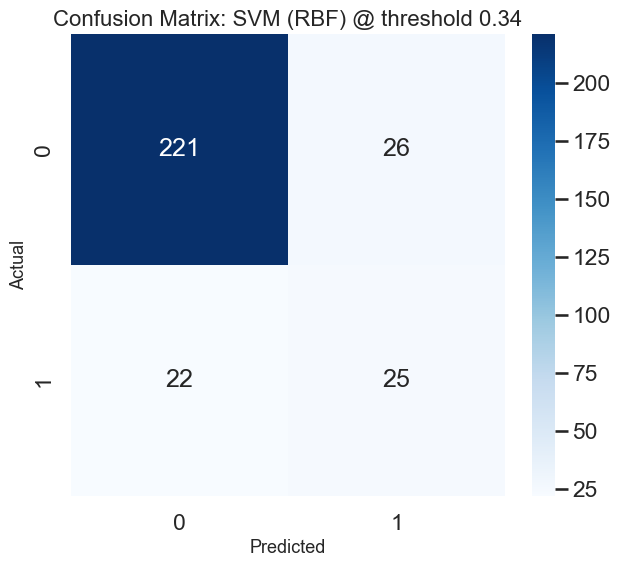

              precision    recall  f1-score   support

No Attrition       0.91      0.89      0.90       247
   Attrition       0.49      0.53      0.51        47

    accuracy                           0.84       294
   macro avg       0.70      0.71      0.71       294
weighted avg       0.84      0.84      0.84       294



In [36]:
final_blackbox_preds = (test_proba_blackbox >= selected_threshold).astype(int)
cm = confusion_matrix(y_test, final_blackbox_preds)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix: {recommended_blackbox_name} @ threshold {selected_threshold:.2f}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test, final_blackbox_preds, target_names=["No Attrition", "Attrition"]))


## 6. Recommendation

The next cell prints a compact conclusion that you can reuse in your capstone write-up.


In [37]:
overall_model_name = best_overall_final["model"]
blackbox_model_name = best_blackbox_final["model"]

# Compute test metrics on-the-fly (they were printed earlier but not stored)
overall_test_proba_local = best_overall_estimator.predict_proba(X_test)[:, 1]
overall_test_pred_local = (overall_test_proba_local >= 0.5).astype(int)

blackbox_test_proba_local = best_blackbox_estimator.predict_proba(X_test)[:, 1]
blackbox_test_pred_local = (blackbox_test_proba_local >= 0.5).astype(int)

# Extract threshold-adjusted metrics
threshold_summary = threshold_test_results.loc[
    threshold_test_results["threshold"] == selected_threshold
].iloc[0]

print("Overall benchmark winner")
print(
    f"- {overall_model_name}: PR-AUC={average_precision_score(y_test, overall_test_proba_local):.3f}, "
    f"ROC-AUC={roc_auc_score(y_test, overall_test_proba_local):.3f}, "
    f"Recall={recall_score(y_test, overall_test_pred_local):.3f}, "
    f"Precision={precision_score(y_test, overall_test_pred_local, zero_division=0):.3f}, "
    f"F1={f1_score(y_test, overall_test_pred_local):.3f}"
)
print()
print("Recommended blackbox model")
print(
    f"- {blackbox_model_name}: PR-AUC={average_precision_score(y_test, blackbox_test_proba_local):.3f}, "
    f"ROC-AUC={roc_auc_score(y_test, blackbox_test_proba_local):.3f}, "
    f"Recall@0.50={recall_score(y_test, blackbox_test_pred_local):.3f}, "
    f"Precision@0.50={precision_score(y_test, blackbox_test_pred_local, zero_division=0):.3f}, "
    f"F1@0.50={f1_score(y_test, blackbox_test_pred_local):.3f}"
)
print(
    f"- Threshold-adjusted blackbox setting ({selected_threshold:.2f}) gives "
    f"Recall={threshold_summary['recall']:.3f}, "
    f"Precision={threshold_summary['precision']:.3f}, "
    f"F1={threshold_summary['f1']:.3f}, "
    f"Balanced Accuracy={threshold_summary['balanced_accuracy']:.3f}"
)
print()
print("Recommendation")
print(
    f"- Keep {overall_model_name} as the performance benchmark."
)
print(
    f"- Use {blackbox_model_name} as the blackbox handoff model for the next XAI phase."
)

Overall benchmark winner
- SVM (RBF): PR-AUC=0.547, ROC-AUC=0.786, Recall=0.319, Precision=0.652, F1=0.429

Recommended blackbox model
- SVM (RBF): PR-AUC=0.547, ROC-AUC=0.786, Recall@0.50=0.319, Precision@0.50=0.652, F1@0.50=0.429
- Threshold-adjusted blackbox setting (0.34) gives Recall=0.532, Precision=0.490, F1=0.510, Balanced Accuracy=0.713

Recommendation
- Keep SVM (RBF) as the performance benchmark.
- Use SVM (RBF) as the blackbox handoff model for the next XAI phase.
